# 04 — Shower-particle 4-vectors (first look)

This notebook inspects the **full Geant4 shower cascade** of a single electromagnetic
event: one 50 GeV photon fired into the silicon-tungsten ECal barrel along +y.

The main pipeline keeps only the *primary* particle and reconstructs a single energy.
Here we instead persist the 4-vector of **every** secondary produced in the shower — the
eventual input to a high-fidelity silicon pixel simulation (**PIXELAV**).

**Units throughout:** momenta / energies / masses in GeV, positions / vertices in mm.

## 1. How this sample was generated — the changes you need

Generating a full-cascade sample is **not** the DDSim default: out of the box, an ECal
shower's secondaries are discarded (see §2). Starting from an ordinary particle-gun
steering, **two** settings make the difference. They live in
[`sim/run_sim_fullcascade.py`](../sim/run_sim_fullcascade.py):

| # | Setting | Why it's needed |
|---|---------|-----------------|
| 1 | `SIM.part.userParticleHandler = ""` | **The key change.** DDSim's default `Geant4TCUserParticleHandler` restricts MC-truth to the inner *tracking* region. ECal shower secondaries are born at r > 1267 mm — outside that region — so they get merged into their parent and never stored. Disabling the user handler removes that region cut. |
| 2 | `SIM.part.keepAllParticles = True` | Keep every Geant4 track as an `MCParticle` (no kinetic-energy pruning / merge-into-parent). |

The output is standard **EDM4hep** ROOT — the same format notebooks 01–03 use. Two practical notes:
- **Keep the steering pure ASCII.** A stray non-ASCII character (em-dash, curly quote) in a
  comment lands in the run metadata and breaks the EDM4hep RunHeader `map<string,string>`
  conversion (see [`docs/troubleshooting.md`](../docs/troubleshooting.md)).
- **Use Key4hep `2026-04-08` (or newer) for the full cascade.** The pinned `2026-02-01`
  podio writer crashes (`free(): invalid pointer`) while *finalizing* a file with this many
  truth particles; `2026-04-08` fixes it. (Standard 1-particle samples are fine on either.)

**To regenerate the sample** (on EAF):

```bash
source /cvmfs/sw.hsf.org/key4hep/setup.sh -r 2026-04-08
export LD_LIBRARY_PATH="$HOME/lib_hack:$LD_LIBRARY_PATH"
cd geometry
ddsim --compactFile SiD_TestBeam.xml \
      --steeringFile ../sim/run_sim_fullcascade.py \
      --numberOfEvents 1
python ../analysis/extract_cascade.py        # EDM4hep ROOT -> models/*.npz (uproot)
```

## 2. What's stored — and what's *extra* in this sample

`ddsim` writes an EDM4hep ROOT `TTree` named **`events`**. The collections we use:

| Collection | EDM4hep type | What it is |
|------------|--------------|------------|
| `MCParticles`    | `MCParticle`        | the truth particles |
| `ECalBarrelHits` | `SimCalorimeterHit` | energy deposits in the silicon |
| (hit contributions) | `CaloHitContribution` | per-step deposit truth, linked back to an `MCParticle` |

**Per `MCParticle`** (note it keeps the momentum and position at *both* ends of the track):

| Branch | Meaning |
|--------|---------|
| `PDG`, `mass`, `charge` | particle identity (PDG code, GeV, e) |
| `momentum.{x,y,z}` / `momentumAtEndpoint.{x,y,z}` | momentum at **production** / at **end** (GeV) |
| `vertex.{x,y,z}` / `endpoint.{x,y,z}` | **production** vertex / **end** point (mm) |
| `generatorStatus`, `simulatorStatus`, `time` | bookkeeping flags |
| `parents_{begin,end}`, `daughters_{begin,end}` | podio relation indices (the cascade tree) |

**Per `ECalBarrelHits` (`SimCalorimeterHit`):** `cellID`, `energy` (GeV), `position` (mm),
plus `contributions_{begin,end}` indexing a **`CaloHitContribution`** collection — one entry
per Geant4 step that deposited in the cell, each with `PDG`, `energy`, `time`, `stepPosition`
and a relation back to the `MCParticle`.

**What PIXELAV actually needs — and why the track endpoints are not enough.** The MCParticle
`vertex`/`endpoint` above bound the *whole track*: where a secondary was created and where it
finally stopped — which may be several sensors away, in the tungsten absorber, or outside the
ECal entirely. PIXELAV instead works **one silicon sensor at a time**. For each charged track
*crossing a given sensor* it wants:
- the **local entry point** on the sensor face,
- the **direction cosines** `cot α = p_x/p_z`, `cot β = p_y/p_z` (track slope in the sensor's
  local frame), and
- the **momentum magnitude** (sets the dE/dx regime).

PIXELAV then transports the straight track across the sensor's *full depletion depth itself*,
so it needs the **entry + direction**, not a separately-stored exit point. That per-crossing
information is **not** the whole-track endpoint — it lives in the per-step `CaloHitContribution`
(each deposit's `stepPosition`, plus the producing particle's direction). Turning those
contributions into per-sensor track segments is exactly experiment "B" /
[`analysis/pixelav_converter.py`](../analysis/pixelav_converter.py).

**The crucial point — the schema is the same, the particle content is not.** Those branches
exist regardless of configuration. What the two settings in §1 change is **which particles
populate `MCParticles`**. The cell below compares a stock-DDSim run against the full-cascade
run for the *same* 50 GeV photon (same random seed → identical hits):

MCParticles stored:   default = 1   |   full cascade = 78,270
ECalBarrelHits:       default = 5395   |   full cascade = 5,395
(same random seed => identical hits; only the truth-particle list differs)


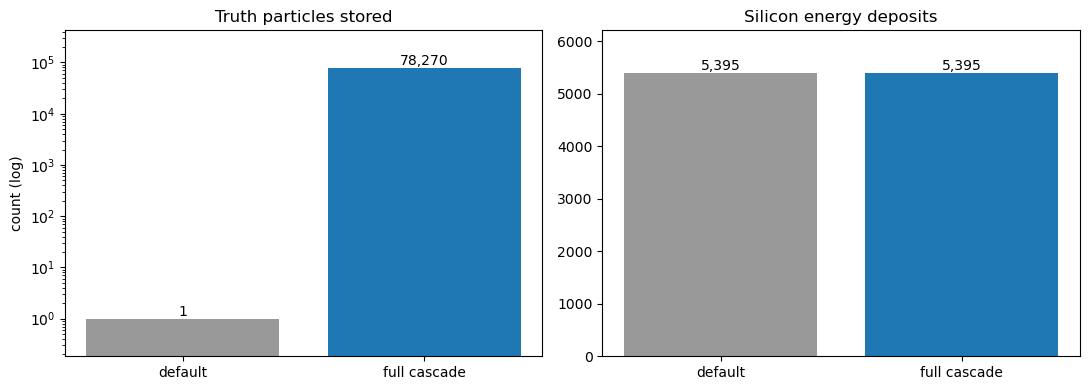

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

def _find(name):
    for p in [os.path.join(os.environ.get("CALOMAPS_HOME", ""), "models", name),
              os.path.join("..", "models", name), os.path.join("models", name)]:
        if p and os.path.exists(p):
            return p
    return None

NPZ_FULL = _find("fullcascade_gamma50_1evt.npz")
NPZ_DEF  = _find("default_gamma50_1evt.npz")
if NPZ_FULL is None:
    raise FileNotFoundError("fullcascade_gamma50_1evt.npz not found — run analysis/extract_cascade.py first.")
d = np.load(NPZ_FULL, allow_pickle=True)

# default-config sample is optional (only for the comparison)
n_def_p = n_def_h = None
if NPZ_DEF:
    dd = np.load(NPZ_DEF, allow_pickle=True)
    n_def_p, n_def_h = len(dd["pdg"]), len(dd["hx"])

n_full_p, n_full_h = len(d["pdg"]), len(d["hx"])
print(f"MCParticles stored:   default = {n_def_p}   |   full cascade = {n_full_p:,}")
print(f"ECalBarrelHits:       default = {n_def_h}   |   full cascade = {n_full_h:,}")
print("(same random seed => identical hits; only the truth-particle list differs)")

if NPZ_DEF:
    fig, ax = plt.subplots(1, 2, figsize=(11, 4))
    for a, (lab, vals, title) in zip(ax, [
            ("MCParticles kept", [n_def_p, n_full_p], "Truth particles stored"),
            ("ECal hits",        [n_def_h, n_full_h], "Silicon energy deposits")]):
        bars = a.bar(["default", "full cascade"], vals, color=["#999999", "#1f77b4"])
        a.set_title(title); a.bar_label(bars, fmt="{:,.0f}")
        a.margins(y=0.15)
    ax[0].set_yscale("log"); ax[0].set_ylabel("count (log)")
    plt.tight_layout(); plt.show()

**Why the particle counts differ so wildly, yet the hits are identical.** Both runs use
the *same* primary photon and the *same* random seed, so Geant4 produces the *same* physical
shower and deposits the *same* energy in the *same* silicon cells — the hit count and total
deposit match exactly (right panel). What `keepAllParticles` / `userParticleHandler` change is
purely **bookkeeping**: whether the truth-particle records are *written out* or merged away.
The detector signal (the hits) never depended on storing the particle list. Keeping the full
cascade simply lets us *also* see the tens of thousands of particles that produced those hits
— which is what we need to eventually feed a pixel-level simulation.

In [2]:
# Pull the full-cascade arrays used by the rest of the notebook
pdg, mass, E = d["pdg"], d["mass"], d["E"]
px, py, pz = d["px"], d["py"], d["pz"]
vsx, vsy, vsz = d["vsx"], d["vsy"], d["vsz"]   # production vertex (mm)
hx, hy, hz, he = d["hx"], d["hy"], d["hz"], d["he"]  # hits (mm, GeV)

print(f"loaded: {NPZ_FULL}")
print(f"arrays: {list(d.keys())}")
print(f"\nN shower particles: {len(pdg):,}   N silicon hits: {len(hx):,}")
print(f"Total deposited E in Si: {he.sum():.3f} GeV  (sampling fraction ~{he.sum()/50:.2%})")
print(f"Primary (particle 0): pdg={pdg[0]}, E={E[0]:.1f} GeV, p=({px[0]:.2f},{py[0]:.1f},{pz[0]:.2f}) GeV")

loaded: /nashome/m/murtazas/CALOMAPS/models/fullcascade_gamma50_1evt.npz
arrays: ['pdg', 'mass', 'px', 'py', 'pz', 'E', 'vsx', 'vsy', 'vsz', 'vex', 'vey', 'vez', 'pid', 'status', 'gstat', 'hx', 'hy', 'hz', 'he', 'meta']

N shower particles: 78,270   N silicon hits: 5,395
Total deposited E in Si: 0.531 GeV  (sampling fraction ~1.06%)
Primary (particle 0): pdg=22, E=50.0 GeV, p=(0.00,50.0,0.00) GeV


## 3. Particle composition

An EM shower grows by two interleaved processes: **pair production** (γ → e⁺e⁻ in a nucleus's
field) and **bremsstrahlung** (e± radiating γ). They feed each other, so the cascade is
overwhelmingly electrons, positrons and photons.

**Why far more electrons than positrons?** Pair production makes e⁺ and e⁻ in equal numbers,
but electrons get three *extra* sources that create no positrons: **ionization / delta rays**
(any charged particle knocking atomic electrons loose), **Compton scattering**, and the
**photoelectric effect** (both eject atomic electrons). Meanwhile positrons are *removed* by
**annihilation** (e⁺ → γγ) at the end of their range. Net effect: e⁻ outnumber e⁺ by about an
order of magnitude here — a real, expected asymmetry, not a bug.

The handful of neutrons, protons and excited tungsten nuclei (PDG `100074xxxx`) come from
**photonuclear** interactions of shower photons with the W absorber.

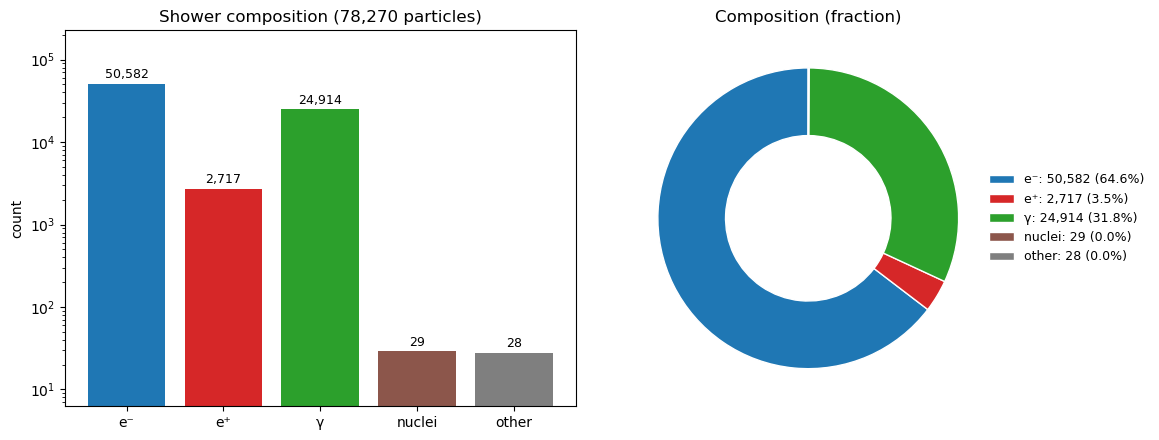

top PDG codes: [(11, 50582), (22, 24914), (-11, 2717), (2112, 24), (2212, 4), (1000741830, 4), (1000741820, 4), (1000741810, 4)]


In [3]:
uniq, counts = np.unique(pdg, return_counts=True)
order = np.argsort(-counts)

# Group: e-, e+, gamma, nuclei (|pdg|>1e9), other
groups = {"e⁻": 0, "e⁺": 0, "γ": 0, "nuclei": 0, "other": 0}
for p, c in zip(uniq, counts):
    if p == 11: groups["e⁻"] += c
    elif p == -11: groups["e⁺"] += c
    elif p == 22: groups["γ"] += c
    elif abs(p) > 1_000_000_000: groups["nuclei"] += c
    else: groups["other"] += c
g = {k: v for k, v in groups.items() if v}
cols = ["#1f77b4", "#d62728", "#2ca02c", "#8c564b", "#7f7f7f"][:len(g)]

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
bars = ax[0].bar(g.keys(), g.values(), color=cols)
ax[0].set_yscale("log"); ax[0].set_ylabel("count")
ax[0].set_title(f"Shower composition ({len(pdg):,} particles)")
ax[0].bar_label(bars, fmt="{:,.0f}", padding=2, fontsize=9)
ax[0].margins(y=0.2)

# Pie: labels go in a legend (avoids overlap on the tiny nuclei/other slices);
# percentages are drawn only on slices large enough to read.
total = sum(g.values())
wedges, _ = ax[1].pie(list(g.values()), colors=cols, startangle=90,
                      wedgeprops=dict(width=0.45, edgecolor="w"))
ax[1].set_title("Composition (fraction)")
ax[1].legend(wedges, [f"{k}: {v:,} ({v/total:.1%})" for k, v in g.items()],
             loc="center left", bbox_to_anchor=(0.95, 0.5), frameon=False, fontsize=9)
plt.tight_layout(); plt.show()
print("top PDG codes:", [(int(uniq[i]), int(counts[i])) for i in order[:8]])

## 4. Energy spectrum

**Left — the spectrum itself.** Each shower generation roughly *halves* the energy while
*doubling* the particle count, so the number of secondaries climbs steeply toward low energy:
a near-power-law fall spanning many decades. Multiplication stops once particles drop below
the ~MeV scale — e± can no longer pair-produce or radiate efficiently (the electron-mass line
at 0.511 MeV marks roughly where this sets in) — so the cascade "dies" into a sea of soft
e±/γ. The few entries far to the right are the *top* of the cascade: the primary and its
first-conversion e⁺e⁻, carrying tens of GeV. (Photons extend to the lowest energies because
they keep being produced by bremsstrahlung and stop multiplying only when they can no longer
pair-produce.)

**Right — where the energy actually is.** The cumulative curve shows the central tension of
calorimetry: although almost all *particles* are soft, almost all the *energy* is carried by
the handful of *hard* particles near the top of the cascade. Yet the measurable **signal**
(the silicon hits) is made by the enormous number of soft particles ionizing the sensors — so
a good calorimeter has to faithfully collect charge from the soft sea, even though the energy
"lives" in a few hard tracks. (Nuclei are excluded here — their "energy" is dominated by
GeV-scale rest mass, not kinematics.)

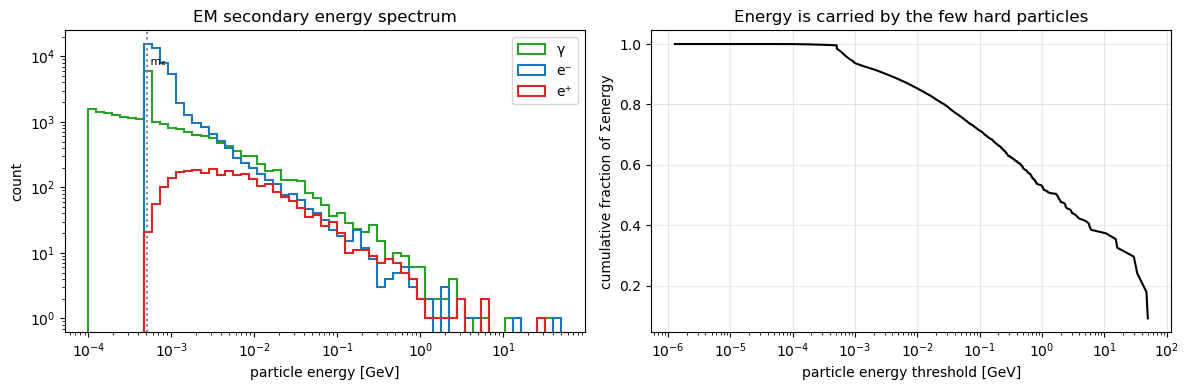

median EM particle energy: 0.66 MeV
# EM particles above 1 GeV: 43 (0.05%)


In [4]:
em = (pdg == 11) | (pdg == -11) | (pdg == 22)
Eem = E[em]
Eem = Eem[Eem > 0]
assert Eem.size, "no EM (e/gamma) particles with E>0 in this event — energy-spectrum plot needs them"

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
bins = np.logspace(np.log10(max(Eem.min(), 1e-4)), np.log10(Eem.max()), 60)
for sel, lab, col in [(pdg == 22, "γ", "#2ca02c"), (pdg == 11, "e⁻", "#1f77b4"), (pdg == -11, "e⁺", "#d62728")]:
    es = E[sel]; es = es[es > 0]
    ax[0].hist(es, bins=bins, histtype="step", label=lab, color=col, lw=1.5)
ax[0].set_xscale("log"); ax[0].set_yscale("log")
ax[0].set_xlabel("particle energy [GeV]"); ax[0].set_ylabel("count")
ax[0].set_title("EM secondary energy spectrum"); ax[0].legend()
ax[0].axvline(0.000511, ls=":", color="grey"); ax[0].text(0.000511, ax[0].get_ylim()[1]*0.3, " mₑ", fontsize=8)

es = np.sort(Eem)[::-1]
ax[1].plot(es, np.cumsum(es)/es.sum(), color="black")
ax[1].set_xscale("log"); ax[1].set_xlabel("particle energy threshold [GeV]")
ax[1].set_ylabel("cumulative fraction of Σenergy"); ax[1].set_title("Energy is carried by the few hard particles")
ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(f"median EM particle energy: {np.median(Eem)*1000:.2f} MeV")
print(f"# EM particles above 1 GeV: {(Eem>1).sum():,} ({(Eem>1).mean():.2%})")

## 5. Longitudinal & radial shower development

The beam travels along +y from the origin; the ECal front face is at r≈1267 mm.
Production vertices show **where** secondaries are born — the classic shower buildup
and decay along depth into the calorimeter.

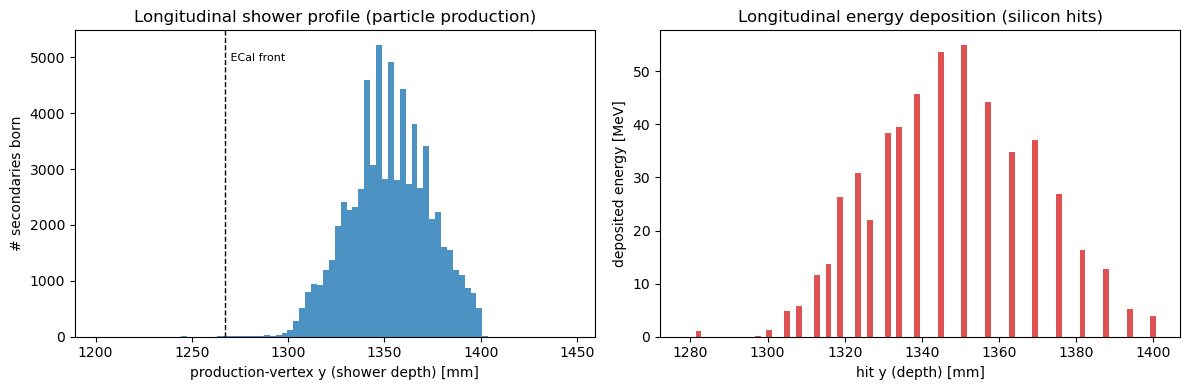

In [5]:
depth = vsy  # mm (production vertex y); for a +y beam, depth into the barrel is y
sel = (depth > 1200) & (depth < 1450) & em   # within the ECal, EM particles

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(depth[sel], bins=80, color="#1f77b4", alpha=0.8)
ax[0].set_xlabel("production-vertex y (shower depth) [mm]"); ax[0].set_ylabel("# secondaries born")
ax[0].set_title("Longitudinal shower profile (particle production)")
ax[0].axvline(1267, ls="--", color="k", lw=1); ax[0].text(1268, ax[0].get_ylim()[1]*0.9, " ECal front", fontsize=8)

ax[1].hist(hy, bins=80, weights=he*1000, color="#d62728", alpha=0.8)
ax[1].set_xlabel("hit y (depth) [mm]"); ax[1].set_ylabel("deposited energy [MeV]")
ax[1].set_title("Longitudinal energy deposition (silicon hits)")
plt.tight_layout(); plt.show()

## 6. Shower shape — transverse spread and 3D view

Transverse coordinates are x and z (the beam is +y). The shower is narrow near the
front and spreads with depth. Below: hit positions colored by deposited energy.

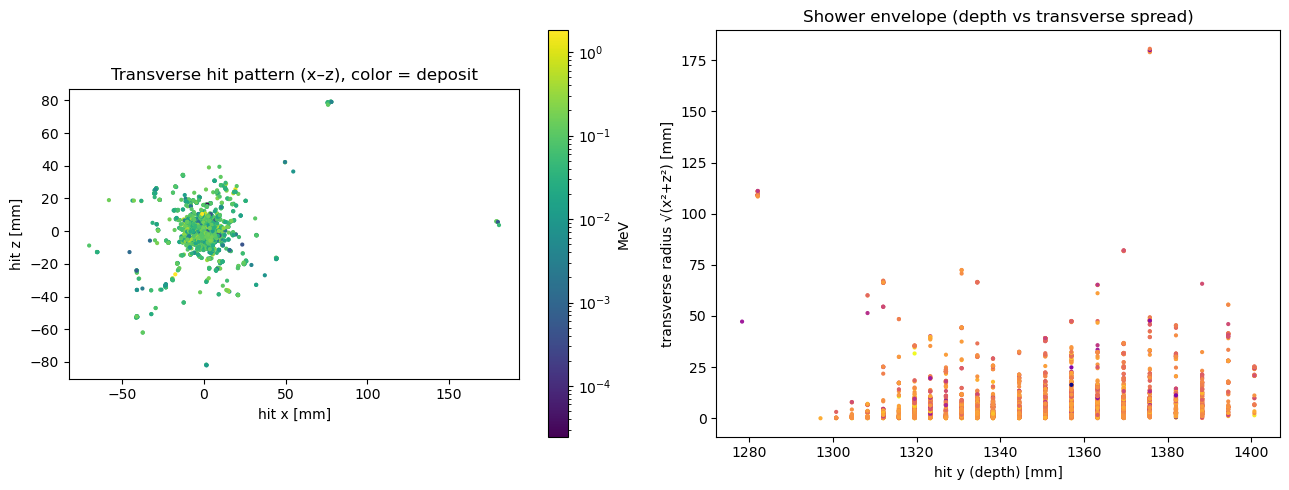

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
sc = ax[0].scatter(hx, hz, c=he*1000, s=4, cmap="viridis", norm=plt.matplotlib.colors.LogNorm())
ax[0].set_xlabel("hit x [mm]"); ax[0].set_ylabel("hit z [mm]"); ax[0].set_aspect("equal")
ax[0].set_title("Transverse hit pattern (x–z), color = deposit"); plt.colorbar(sc, ax=ax[0], label="MeV")

rt = np.hypot(hx, hz)
ax[1].scatter(hy, rt, c=he*1000, s=4, cmap="plasma", norm=plt.matplotlib.colors.LogNorm())
ax[1].set_xlabel("hit y (depth) [mm]"); ax[1].set_ylabel("transverse radius √(x²+z²) [mm]")
ax[1].set_title("Shower envelope (depth vs transverse spread)")
plt.tight_layout(); plt.show()

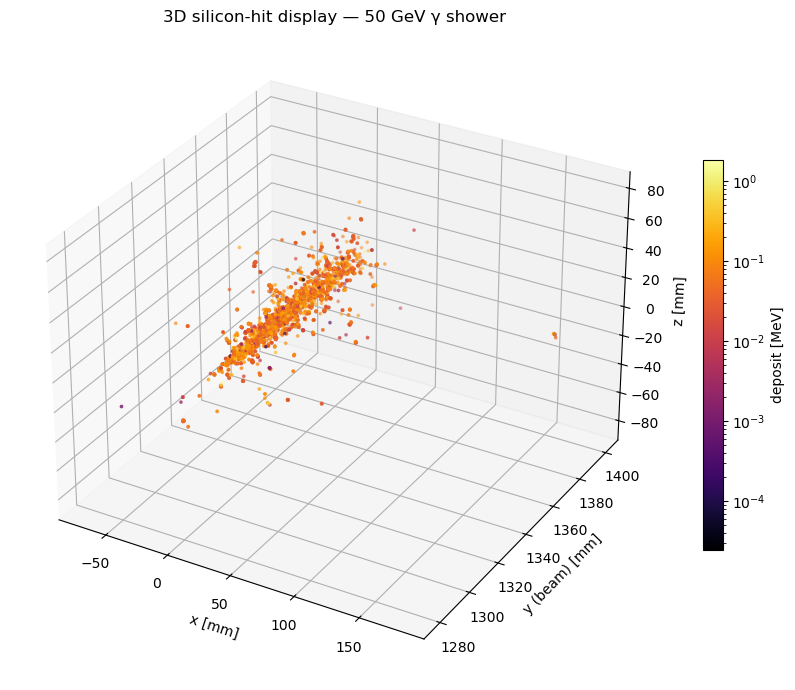

In [7]:
from mpl_toolkits.mplot3d import Axes3D  # noqa
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")
sub = slice(None) if len(hx) < 20000 else np.random.default_rng(0).choice(len(hx), 20000, replace=False)
p = ax.scatter(hx[sub], hy[sub], hz[sub], c=he[sub]*1000, s=3, cmap="inferno",
               norm=plt.matplotlib.colors.LogNorm())
ax.set_xlabel("x [mm]"); ax.set_ylabel("y (beam) [mm]"); ax.set_zlabel("z [mm]")
ax.set_title("3D silicon-hit display — 50 GeV γ shower")
fig.colorbar(p, label="deposit [MeV]", shrink=0.6)
plt.tight_layout(); plt.show()

## 7. Momentum directions

Secondaries are produced predominantly forward (+y, following the primary) but with a
real angular spread that grows for softer particles — this opening-angle information is
exactly what a pixel-level simulation needs per track.

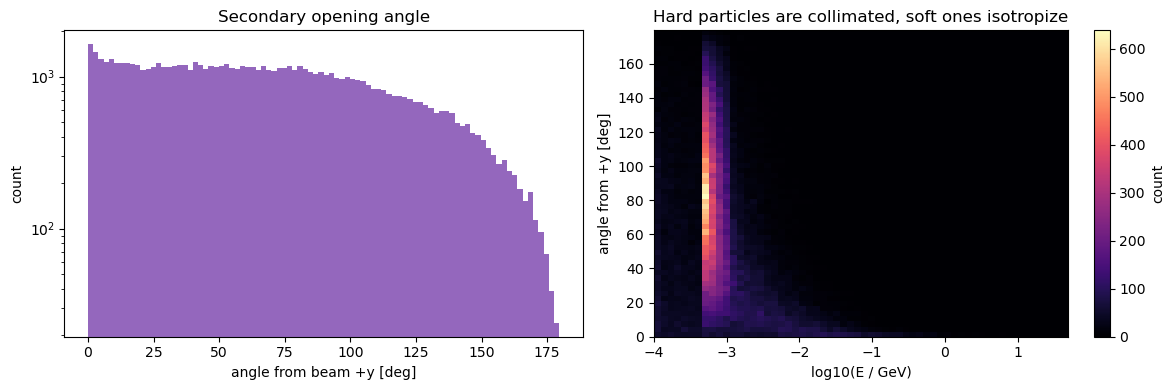

In [8]:
pmag = np.sqrt(px**2 + py**2 + pz**2)
good = (pmag > 0) & em
cos_t = py[good] / pmag[good]
theta = np.degrees(np.arccos(np.clip(cos_t, -1, 1)))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(theta, bins=90, color="#9467bd")
ax[0].set_xlabel("angle from beam +y [deg]"); ax[0].set_ylabel("count")
ax[0].set_title("Secondary opening angle"); ax[0].set_yscale("log")

sc = ax[1].hist2d(np.log10(np.clip(E[good], 1e-4, None)), theta, bins=[60, 60], cmap="magma")
ax[1].set_xlabel("log10(E / GeV)"); ax[1].set_ylabel("angle from +y [deg]")
ax[1].set_title("Hard particles are collimated, soft ones isotropize")
plt.colorbar(sc[3], ax=ax[1], label="count")
plt.tight_layout(); plt.show()

## Summary & next steps

- We can extract the **complete shower cascade** (tens of thousands of particles for a
  50 GeV γ): every secondary's PDG, 4-vector and production/end vertex — vs just the
  primary by default (see the §2 comparison).
- Physics checks out: pair-conversion of the primary, brem/pair cascade, a per-cent-level
  W/Si sampling fraction, forward-peaked but spreading secondaries.

**Toward PIXELAV:** PIXELAV needs, per charged track crossing a sensor, the local
**entry/exit points, direction cosines, and momentum**. That is *per-sensor step-level*
information (experiment "B") — the EDM4hep `CaloHitContribution` records on each
`SimCalorimeterHit` (per-step `PDG`, `energy`, `stepPosition`, + a link back to the
`MCParticle`) are the natural source, and are not yet pulled into the `.npz`. See
[`analysis/pixelav_converter.py`](../analysis/pixelav_converter.py) (scaffold).